**1. 한글 깨짐 현상 **


(1) !apt-get install -y fonts-nanum : 패지키 관리자를 통해 글꼴을 설치해달라 명령하는 것
(2) !fc-cache-fv : 글꼴을 시스템이 제대로 인식할 수 있도록 글꼴 정보 보관함을 강제로 업데이트하는 명령
- -f(force) : \새로 강제로 만들다
- -v(verbose) : 진행과정을 화면에 보여주는 것

In [ ]:
!apt-get install -y fonts-nanum
!fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

**2. 머신러닝 설명용 라이브러리 설치**


(1) SHAP이 필요한 이유? 머신러닝이나 딥러닝은 성능은 좋으나 내부 구조가 부족하여 사람들이 이해하기 힘듦. SHAP은 인공지능 애부를 들여다보고 어떤 데이터가 예측 결과에 영향을 죽었는지 기여도를 계산해서 시각화해줌 .

In [ ]:
!pip install shap

3. 라이브러리 임포트

[데이터 기본 조작 및 시각화]
(1) pandas as pd : 데이터를 불러오고, 정렬하고 빈 곳을 채우는 등 데이터 전처리의 90%을 담당
(2) numpy as np : 수학 계산, 행렬 연산, 숫자 배열을 처리하기 위한 라이브러리
(3) matplotlib.pylot as plt : 데이터를 시각화해주는 도구

[머신러닝 데이터 준비 및 전처리]
(1) from sklearn.model_selection import train_test_split : 데이터를 '학습용 데이터'와 '시험용 데이터'로 나눔
(2) from sklearn.preprocessing import StandardScaler : 데이터 단위를 맞춰주는 표준화 도구

[머신러닝 AI 모델]
(1) from sklearn.linear_model imort LogisticRegression : 분류 모델
(2) from sklearn.ensemble import RandomForestClassifer : 여러 개의 결정 트리를 수없이 만들어서 의견을 종합해 최종 답을 내리는 앙상블 머신러닝 모델


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
import shap

In [ ]:
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

2. 데이터셋 로드 및 통합

강시현(님) 데이터 : diabetes.csv

In [ ]:
try:
    df1 = pd.read_csv('diabetes.csv')
    df1_mod = pd.DataFrame({
        'Age': df1['Age'], 'Gender': 'Female', 'BMI': df1['BMI'],
        'Glucose': df1['Glucose'], 'HighBloodPressure': np.where(df1['BloodPressure'] >= 130, 1, 0),
        'Smoking': np.random.choice([0, 1], size=len(df1)),  # 기존 데이터에 없을 경우 가상 생성
        'Target_Diabetes': df1['Outcome']
    })
except FileNotFoundError:
    df1_mod = pd.DataFrame()

박신영(님) 데이터 : diabetes_prediction_dataset.csv

In [ ]:
try:
    df2 = pd.read_csv('diabetes_prediction_dataset.csv')
    # 흡연 데이터 변환 (No Info, never, current 등 -> 0과 1로 변환)
    smoking_map = {'never': 0, 'No Info': 0, 'current': 1, 'former': 1, 'not current': 0, 'ever': 1}
    df2_mod = pd.DataFrame({
        'Age': df2['age'], 'Gender': df2['gender'], 'BMI': df2['bmi'],
        'Glucose': df2['blood_glucose_level'], 'HighBloodPressure': df2['hypertension'],
        'Smoking': df2['smoking_history'].map(smoking_map).fillna(0).astype(int),
        'Target_Diabetes': df2['diabetes']
    })
except FileNotFoundError:
    df2_mod = pd.DataFrame()

엄정현(님) 데이터 : obesity_data.csv

In [ ]:
try:
    df3 = pd.read_csv('obesity_data.csv')
    df3_mod = pd.DataFrame({
        'Age': df3['Age'], 'Gender': df3['Gender'], 'BMI': df3['BMI'],
        'Glucose': np.nan, 'HighBloodPressure': np.nan, 'Smoking': np.nan, 'Target_Diabetes': np.nan
    })
except FileNotFoundError:
    df3_mod = pd.DataFrame()

**3.가상의 기본 더미 데이터셋 (모든 파일이 없을 때 코드 에러를 방지하기 위함)**

[if 구문] : 파일이 전부 X
- 원리 : and 조건이므로 df1_mod, df2_mod, df3_mod 3개의 데이터프레임이 모두 비어있을 때만 가능
- 파일이 없다는 이유로 에러로 죽이는 것이 아니라 분석 연습이나 데모 시연을 할 수 있도록 Numpy를 이용해 500명 분량의 가상 데이터(demo_data)를 무작위로 창조

[else 구문] : 파일이 전부 존재

(1) pd.concat() : 데이터를 이어붙이는 (Concatenate) 함수

In [ ]:
if df1_mod.empty and df2_mod.empty and df3_mod.empty:
    print("※ 경고: 팀원들의 CSV 파일을 찾을 수 없어 데모용 샘플 데이터를 임의 생성합니다.")
    demo_data = {
        'Age': np.random.randint(20, 80, 500),
        'Gender': np.random.choice(['Male', 'Female'], 500),
        'BMI': np.random.uniform(16, 38, 500),
        'Glucose': np.random.randint(70, 200, 500),
        'HighBloodPressure': np.random.choice([0, 1], 500, p=[0.7, 0.3]),
        'Smoking': np.random.choice([0, 1], 500, p=[0.6, 0.4]),
        'Target_Diabetes': np.random.choice([0, 1], 500, p=[0.8, 0.2])
    }
    combined_df = pd.DataFrame(demo_data)
else:
    combined_df = pd.concat([df1_mod, df2_mod, df3_mod], ignore_index=True)

※ 경고: 팀원들의 CSV 파일을 찾을 수 없어 데모용 샘플 데이터를 임의 생성합니다.


**4. 데이터 정제 및 성별 통일**

[왜 했는가?]
1.   성별데이터의 대소문자 불일치(예: male, mAle, MALE 등) 해결하기 위함.


In [ ]:
combined_df = combined_df[combined_df['Gender'].astype(str).str.capitalize().isin(['Male', 'Female'])]
combined_df['Gender'] = combined_df['Gender'].astype(str).str.capitalize()

**5. 비만도 타겟 변수 생성**

BMI 숫자를 바탕으로, 비만도 등급을 판별


1. combined_df['BMI'].apply(get_obesity_risk_str) : 데이터 프레임의 특정 열 뒤에 .apply(함수명)을 붙이면, for문을 복잡하게 돌리지 않고 해당 열의 데이터를 위에서부터 아래로 한 행씩 가져와서 함수에 대입해줌.






In [ ]:
def get_obesity_risk_str(bmi):
    if bmi < 18.5: return '저체중'
    elif bmi < 23.0: return '정상 체중'
    elif bmi < 25.0: return '과체중'
    elif bmi < 30.0: return '경도 비만'
    else: return '고도 비만'

combined_df['Target_Obesity'] = combined_df['BMI'].apply(get_obesity_risk_str)

**5-1. 결측치 채우기**


[데이터가 없을 시]
1. 혈당(Glucose) : 전체 평균치
2. 고혈압/흡연 : 0으로 간주
3. 당뇨 결과 : 모르면 0, AI학습에 적합하게 소수점을 떼어낸 정수 형태 변환



In [ ]:
combined_df['Glucose'] = combined_df['Glucose'].fillna(combined_df['Glucose'].mean())
combined_df['HighBloodPressure'] = combined_df['HighBloodPressure'].fillna(0)
combined_df['Smoking'] = combined_df['Smoking'].fillna(0)
combined_df['Target_Diabetes'] = combined_df['Target_Diabetes'].fillna(0).astype(int)

**6. 데이터 인코딩 및 모델 학습**

로지스틱 회귀나 랜덤포레스트 같은 알고리즘은 'Female', '정상체중'과 같은 글자를 그대로 입력받으면 연산을 할 수 없어서 에러를 냄. >> 글자를 0,1,2 같은 숫자로 번역하는 작업 필수 = sklearn의 LabelEncoder가 해당 역할을 함.

In [ ]:
from sklearn.preprocessing import LabelEncoder

le_gender = LabelEncoder()
combined_df['Gender_Encoded'] = le_gender.fit_transform(combined_df['Gender'])

le_target_obesity = LabelEncoder()
combined_df['Target_Obesity_Encoded'] = le_target_obesity.fit_transform(combined_df['Target_Obesity'])

In [ ]:
le_gender = LabelEncoder()
combined_df['Gender_Encoded'] = le_gender.fit_transform(combined_df['Gender'])

le_target_obesity = LabelEncoder()
combined_df['Target_Obesity_Encoded'] = le_target_obesity.fit_transform(combined_df['Target_Obesity'])

**6-2. 비만 모델 학습 데이터 (Age, Gender, BMI 사용)**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

X_ob = combined_df[['Age', 'Gender_Encoded', 'BMI']]
y_ob = combined_df['Target_Obesity_Encoded']
X_train_ob, X_test_ob, y_train_ob, y_test_ob = train_test_split(X_ob, y_ob, test_size=0.2, random_state=42, stratify=y_ob)

scaler_ob = StandardScaler()
X_train_ob_scaled = scaler_ob.fit_transform(X_train_ob)
X_test_ob_scaled = scaler_ob.transform(X_test_ob)



**6-3. 당뇨 모델 학습 데이터**

In [ ]:
X_diab = combined_df[['Age', 'Gender_Encoded', 'BMI', 'Glucose', 'HighBloodPressure', 'Smoking']]
y_diab = combined_df['Target_Diabetes']
X_train_diab, X_test_diab, y_train_diab, y_test_diab = train_test_split(X_diab, y_diab, test_size=0.2, random_state=42, stratify=y_diab)

scaler_diab = StandardScaler()
X_train_diab_scaled = scaler_diab.fit_transform(X_train_diab)
X_test_diab_scaled = scaler_diab.transform(X_test_diab)

print("▶ AI 머신러닝 모델 학습 완료. (비만 및 당뇨 예측 모델 최적화)")

▶ AI 머신러닝 모델 학습 완료. (비만 및 당뇨 예측 모델 최적화)


**6-4. Logistic Regression vs Random Forest 모델 성능 비교 **

(1) 비만 예측 모델 알고리즘 성능
- 랜덤 포레스트의 정확도가 더 높음
- 비만 데이터는 bmi나 혈당 같은 변수들의 비선형적으로 복잡하게 얽혀있을 확률이 높아, 이를 트리 기반의 랜덤 포레스트가 훨씬 유연하게 잘 잡아내줌

(2) 당뇨 예측 모델 알고리즘 성능
- 데이터 불균형 상태


 ⚙️ [AI 인공지능 엔진] 모델 알고리즘 성능 비교 검증 시작
              Model   Target  Accuracy  F1-Score
Logistic Regression  Obesity      0.89    0.8716
      Random Forest  Obesity      0.97    0.9691
Logistic Regression Diabetes      0.78    0.0000
      Random Forest Diabetes      0.74    0.0714


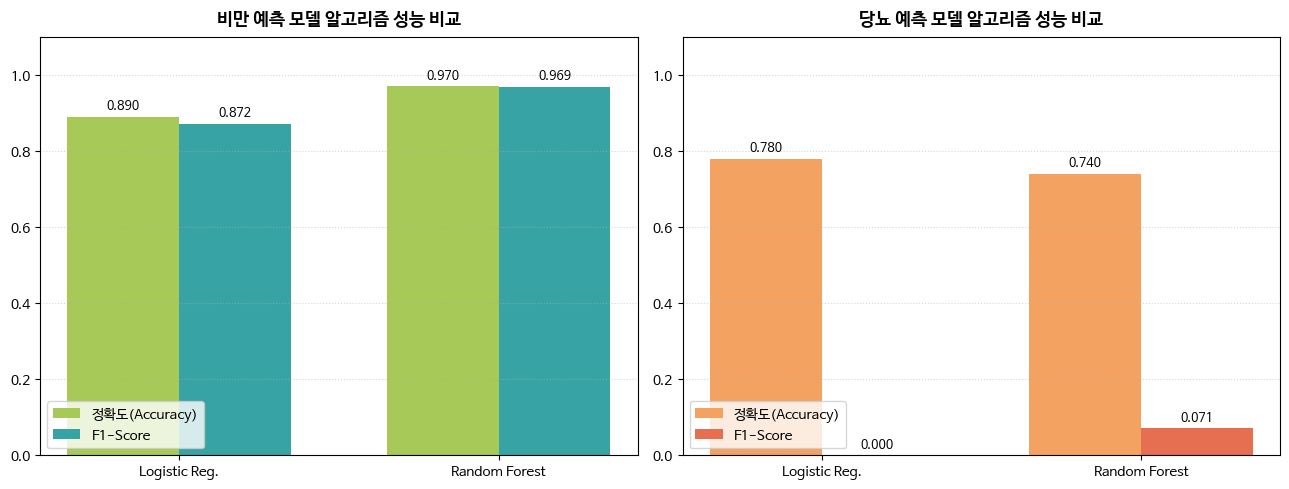

In [ ]:
print("\n" + "="*60)
print(" ⚙️ [AI 인공지능 엔진] 모델 알고리즘 성능 비교 검증 시작")
print("="*60)

# --- [비만 모델 알고리즘 비교 학습] ---
lr_obesity = LogisticRegression(max_iter=1000, random_state=42)
model_obesity = RandomForestClassifier(random_state=42) # 기존 코드의 예측 함수와 호환을 위해 변수명 유지

lr_obesity.fit(X_train_ob_scaled, y_train_ob)
model_obesity.fit(X_train_ob_scaled, y_train_ob)

lr_ob_pred = lr_obesity.predict(X_test_ob_scaled)
rf_ob_pred = model_obesity.predict(X_test_ob_scaled)

ob_results = {
    "Model": ["Logistic Regression", "Random Forest"],
    "Target": ["Obesity", "Obesity"],
    "Accuracy": [accuracy_score(y_test_ob, lr_ob_pred), accuracy_score(y_test_ob, rf_ob_pred)],
    "F1-Score": [f1_score(y_test_ob, lr_ob_pred, average='weighted'), f1_score(y_test_ob, rf_ob_pred, average='weighted')]
}

# --- [당뇨 모델 알고리즘 비교 학습] ---
lr_diabetes = LogisticRegression(max_iter=1000, random_state=42)
model_diabetes = RandomForestClassifier(random_state=42) # 기존 코드의 예측 함수와 호환을 위해 변수명 유지

lr_diabetes.fit(X_train_diab_scaled, y_train_diab)
model_diabetes.fit(X_train_diab_scaled, y_train_diab)

lr_diab_pred = lr_diabetes.predict(X_test_diab_scaled)
rf_diab_pred = model_diabetes.predict(X_test_diab_scaled)

diab_results = {
    "Model": ["Logistic Regression", "Random Forest"],
    "Target": ["Diabetes", "Diabetes"],
    "Accuracy": [accuracy_score(y_test_diab, lr_diab_pred), accuracy_score(y_test_diab, rf_diab_pred)],
    "F1-Score": [f1_score(y_test_diab, lr_diab_pred, average='binary'), f1_score(y_test_diab, rf_diab_pred, average='binary')]
}

# --- [성능 비교 수치 표 출력] ---
df_comparison = pd.concat([pd.DataFrame(ob_results), pd.DataFrame(diab_results)], ignore_index=True)
print(df_comparison.round(4).to_string(index=False))
print("="*60)

# --- [성능 비교 막대그래프 시각화 출력] ---
fig_comp, axes_comp = plt.subplots(1, 2, figsize=(13, 5))
x_idx = np.arange(2)
width = 0.35

# 1. 비만 모델 성능 비교 시각화
axes_comp[0].bar(x_idx - width/2, df_comparison.loc[0:1, 'Accuracy'], width, label='정확도(Accuracy)', color='#a7c957')
axes_comp[0].bar(x_idx + width/2, df_comparison.loc[0:1, 'F1-Score'], width, label='F1-Score', color='#38a3a5')
axes_comp[0].set_title('비만 예측 모델 알고리즘 성능 비교', fontsize=13, fontweight='bold', pad=10)
axes_comp[0].set_xticks(x_idx)
axes_comp[0].set_xticklabels(["Logistic Reg.", "Random Forest"])
axes_comp[0].set_ylim(0, 1.1)
axes_comp[0].legend(loc='lower left')
axes_comp[0].grid(axis='y', linestyle=':', alpha=0.5)

# 바 위에 수치 텍스트 표시
for i in range(2):
    axes_comp[0].text(i - width/2, df_comparison.loc[i, 'Accuracy'] + 0.02, f"{df_comparison.loc[i, 'Accuracy']:.3f}", ha='center', fontsize=9)
    axes_comp[0].text(i + width/2, df_comparison.loc[i, 'F1-Score'] + 0.02, f"{df_comparison.loc[i, 'F1-Score']:.3f}", ha='center', fontsize=9)

# 2. 당뇨 모델 성능 비교 시각화
axes_comp[1].bar(x_idx - width/2, df_comparison.loc[2:3, 'Accuracy'], width, label='정확도(Accuracy)', color='#f4a261')
axes_comp[1].bar(x_idx + width/2, df_comparison.loc[2:3, 'F1-Score'], width, label='F1-Score', color='#e76f51')
axes_comp[1].set_title('당뇨 예측 모델 알고리즘 성능 비교', fontsize=13, fontweight='bold', pad=10)
axes_comp[1].set_xticks(x_idx)
axes_comp[1].set_xticklabels(["Logistic Reg.", "Random Forest"])
axes_comp[1].set_ylim(0, 1.1)
axes_comp[1].legend(loc='lower left')
axes_comp[1].grid(axis='y', linestyle=':', alpha=0.5)

# 바 위에 수치 텍스트 표시
for i in range(2):
    idx = i + 2
    axes_comp[1].text(i - width/2, df_comparison.loc[idx, 'Accuracy'] + 0.02, f"{df_comparison.loc[idx, 'Accuracy']:.3f}", ha='center', fontsize=9)
    axes_comp[1].text(i + width/2, df_comparison.loc[idx, 'F1-Score'] + 0.02, f"{df_comparison.loc[idx, 'F1-Score']:.3f}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

**7. 중요도 추출**

랜덤 포레스트 모델이 예측을 할 대 지분을 가장 많이 차지한 우수 변수들이 무엇인지 전체 데이터 기준으로 순위를 매겨 가로 막대그래프로 보여주는 코드

In [ ]:
def plot_global_explanation():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 1. 비만 모델 특성 중요도
    importances_ob = model_obesity.feature_importances_
    indices_ob = np.argsort(importances_ob)
    axes[0].barh(range(X_ob.shape[1]), importances_ob[indices_ob], color='g', align='center')
    axes[0].set_yticks(range(X_ob.shape[1]))
    axes[0].set_yticklabels([X_ob.columns[i] for i in indices_ob])
    axes[0].set_title('비만 예측 모델 변수 중요도 (Global)')
    axes[0].set_xlabel('중요도 (Relative Importance)')

    # 2. 당뇨 모델 특성 중요도
    importances_diab = model_diabetes.feature_importances_
    indices_diab = np.argsort(importances_diab)
    axes[1].barh(range(X_diab.shape[1]), importances_diab[indices_diab], color='b', align='center')
    axes[1].set_yticks(range(X_diab.shape[1]))
    axes[1].set_yticklabels([X_diab.columns[i] for i in indices_diab])
    axes[1].set_title('당뇨 예측 모델 변수 중요도 (Global)')
    axes[1].set_xlabel('중요도 (Relative Importance)')

    plt.tight_layout()
    plt.show()

**7-1. 중요도 출력**

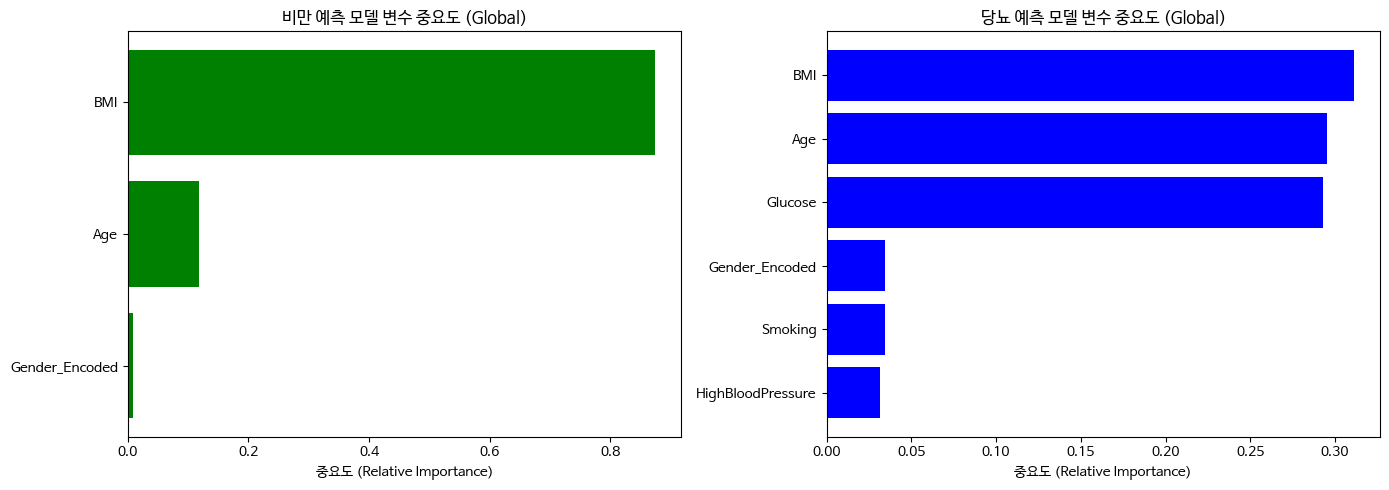

In [ ]:
plot_global_explanation()

**7. 통합 예측 및 가이드라인 출력 함수**

In [ ]:
MEDICAL_DICTIONARY = {
    "수축기 혈압": "심장이 피를 온몸으로 짜낼 때, 혈관이 받는 '가장 높은 압력'이에요. 흔히 '최고 혈압' 혹은 '앞에 혈압'이라고도 불러요.",
    "이완기 혈압": "심장이 피를 다 짜내고 다시 쉴 때, 혈관에 남은 '가장 낮은 압력'이에요. 흔히 '최저 혈압' 혹은 '뒤에 혈압'이라고 해요.",
    "공복 혈당": "아침에 일어나서 아무것도 먹지 않은 빈속(8시간 이상)일 때 측정한 피 속의 설탕 수치예요. 당뇨를 진단하는 중요한 기준이 됩니다.",
    "당화혈색소": "최근 2~3달 동안 내 몸속의 평균 혈당이 어땠는지 보여주는 성적표예요. 하루 이틀 굶는다고 속일 수 없는 아주 정확한 당뇨 점수랍니다.",
    "체질량지수(BMI)": "내 키에 비해서 몸무게가 적당한지, 혹은 뚱뚱한지를 숫자로 계산해 본 '비만도 성적표'예요.",
    "고혈압": "혈관의 압력이 정상보다 높아서 혈관 벽이 지치고 있는 상태예요. 방치하면 혈관이 막힐 수 있어 약이나 식단으로 꼭 낮춰야 해요.",
    "대사증후군": "배가 많이 나오고, 혈압도 높고, 혈당도 높고, 피에 기름기도 끼는 증상들이 한꺼번에 찾아온 상태예요. 만성질환의 종합선물세트 같아서 관리가 필요해요.",
    "중성지방": "우리가 밥이나 빵을 먹고 남은 에너지가 뱃살이나 핏속에 기름 형태로 저장된 거예요. 너무 많으면 피가 끈적해져서 안 좋아요.",
    "콜레스테롤": "핏속을 돌아다니는 기름기 성분이에요. 좋은 콜레스테롤(HDL)은 혈관을 청소해 주고, 나쁜 콜레스테롤(LDL)은 혈관을 막히게 해요.",
    "당뇨병": "몸속에서 인슐린이라는 열쇠가 제대로 작동하지 않아, 밥을 먹어도 기운으로 가지 못하고 오줌으로 설탕(당)이 섞여 나오는 병이에요."
}

In [ ]:
def predict_health_risk():
    print("\n" + "="*60)
    print(" [비만 & 당뇨 통합 위험도 측정 및 맞춤 건강 피드백 시스템] ")
    print("="*60)

    try:
        # 1. 사용자 기본 정보 입력 인터페이스
        name_input = input("1. 이름을 입력하세요 : ").strip().capitalize()
        age = float(input("2. 나이를 입력하세요 (예: 72): "))
        gender_input = input("3. 성별을 입력하세요 (Male / Female): ").strip().capitalize()
        height = float(input("4. 키를 cm 단위로 입력하세요 (예: 165): "))
        weight = float(input("5. 몸무게를 kg 단위로 입력하세요 (예: 74): "))

        print("\n[흡연 및 혈압 수치를 추가로 입력해 주세요]")
        smoke_input = input("6. 현재 흡연 중이십니까? (Y / N): ").strip().upper()
        sbp = float(input("7-1. 최고 혈압(수축기)을 입력하세요 (mmHg) (예: 135): "))
        dbp = float(input("7-2. 최저 혈압(이완기)을 입력하세요 (mmHg) (예: 85): "))
        glucose = float(input("8. 공복 혈당 수치를 입력하세요 (mg/dL) (예: 205): "))

        # 텍스트 데이터 매핑 및 기존 인코더 안전 결합
        if gender_input not in ['Male', 'Female']:
            gender_input = 'Male'
        gender_encoded = le_gender.transform([gender_input])[0]

        smoking = 1 if smoke_input == 'Y' else 0
        high_bp = 1 if (sbp >= 130 or dbp >= 80) else 0

        # BMI 수식 계산
        height_m = height / 100
        bmi = weight / (height_m ** 2)

        # 2. AI 모델 기반 1차 예측
        user_data_ob = pd.DataFrame([[age, gender_encoded, bmi]], columns=['Age', 'Gender_Encoded', 'BMI'])
        user_data_ob_scaled = scaler_ob.transform(user_data_ob)
        pred_ob_encoded = model_obesity.predict(user_data_ob_scaled)[0]
        pred_ob_class = le_target_obesity.inverse_transform([pred_ob_encoded])[0]

        user_data_diab = pd.DataFrame([[age, gender_encoded, bmi, glucose, high_bp, smoking]],
                                       columns=['Age', 'Gender_Encoded', 'BMI', 'Glucose', 'HighBloodPressure', 'Smoking'])
        user_data_diab_scaled = scaler_diab.transform(user_data_diab)

        # 기본 AI 모델 결과 도출
        ai_pred_diab = model_diabetes.predict(user_data_diab_scaled)[0]
        ai_pred_proba = model_diabetes.predict_proba(user_data_diab_scaled)[0][1] * 100

        # ------------------------------------------------------------------
        # 🔥 [핵심 추가] 의학 지침 기반 AI 결과 보정 및 안전장치 (Rule-based Safeguard)
        # ------------------------------------------------------------------
        final_pred_diab = ai_pred_diab
        final_pred_proba = ai_pred_proba
        safeguard_triggered = False

        # 의학 기준: 공복 혈당 126 mg/dL 이상은 당뇨병 확진 상태
        if glucose >= 126:
            final_pred_diab = 1
            safeguard_triggered = True
            # 혈당 수치에 비례하여 시각화 확률 보정 (200 이상이면 무조건 위험 게이지 끝자락으로 이동)
            if glucose >= 200:
                final_pred_proba = max(95.0, ai_pred_proba)
            elif glucose >= 150:
                final_pred_proba = max(80.0, ai_pred_proba)
            else:
                final_pred_proba = max(71.0, ai_pred_proba)
        # 공복 혈당 100 ~ 125 mg/dL 사이는 당뇨 전단계 (주의 구간)
        elif 100 <= glucose < 126:
            final_pred_proba = max(45.0, ai_pred_proba)

        # 적정 조절 체중 계산
        normal_weight_min = 18.5 * (height_m ** 2)
        normal_weight_max = 23.0 * (height_m ** 2)

        weight_guide = ""
        if bmi < 18.5:
            gain_needed = normal_weight_min - weight
            weight_guide = f"☞ 현재 저체중 상태입니다. 정상 범위에 도달하기 위해 최소 [ {gain_needed:.1f}kg 증가 ] 가 필요합니다."
        elif bmi >= 23.0:
            loss_needed = weight - normal_weight_max
            weight_guide = f"☞ 현재 과체중 혹은 비만 상태입니다. 정상 범위에 도달하기 위해 최소 [ {loss_needed:.1f}kg 감량 ] 이 필요합니다."
        else:
            weight_guide = f"☞ 축하합니다! 현재 정상 체중 유지 중입니다. (적정 범위: {normal_weight_min:.1f}kg ~ {normal_weight_max:.1f}kg)"

        # 3. 종합 성적표 출력문
        print("\n" + "="*60)
        print(f" ▣ {name_input} 어르신의 종합 건강 성적표")
        print("="*60)
        print(f" * 나의 현재 몸무게 상태 : {pred_ob_class} (BMI 점수: {bmi:.1f})")

        if safeguard_triggered:
            print(f" * 당뇨병 위험도 예측    : [위험 (공복혈당 {glucose:.0f}mg/dL로 인해 즉각적인 의사 진료 필요!)]")
        else:
            print(f" * 당뇨병 위험도 예측    : [{'위험 (관리가 시급합니다)' if final_pred_diab == 1 else '안전 (지금처럼 유지하세요)'}] ")

        print(f" * 당뇨병 발생 가능성    : {final_pred_proba:.1f}%")
        print("-"*60)
        print(weight_guide)
        print("="*60)

        # 4. 시각화 그래픽 구현
        print("\n[ 안내 ] 어르신의 건강 상태 그래프를 화면에 띄웁니다...")
        fig, axes = plt.subplots(2, 1, figsize=(10, 8))

        # BMI 그래프
        bmi_categories = ['저체중', '정상', '과체중', '경도비만', '비만', '고도비만']
        axes[0].barh(bmi_categories, [18.5, 4.5, 2.0, 5.0, 5.0, 10.0],
                     left=[0, 18.5, 23, 25, 30, 35],
                     color=['#5fa8d3', '#a7c957', '#f4a261', '#e76f51', '#cf1b1b', '#800000'], alpha=0.6)
        axes[0].axvline(x=bmi, color='black', linestyle='--', linewidth=2)
        axes[0].plot(bmi, bmi_categories[min(int(bmi//6), 5)], 'ro', markersize=15, label=f'내 몸무게 위치 ({bmi:.1f})')
        axes[0].set_title(f'① {name_input}님의 체중(BMI) 위치 확인표', fontsize=14, fontweight='bold', pad=15)
        axes[0].set_xlim(10, 45)
        axes[0].legend(loc='upper right', fontsize=11)

        # 당뇨병 위험도 안전 신호등 게이지 바 (보정된 final_pred_proba 사용)
        axes[1].barh(['당뇨 위험도'], [40], color='#a7c957', label='안전 (0~40%)')
        axes[1].barh(['당뇨 위험도'], [30], left=[40], color='#ffb703', label='주의 (41~70%)')
        axes[1].barh(['당뇨 위험도'], [30], left=[70], color='#cf1b1b', label='위험 (71~100%)')
        axes[1].axvline(x=final_pred_proba, color='black', linestyle='-', linewidth=3)
        axes[1].plot(final_pred_proba, 0, 'y*', markersize=20, markeredgecolor='black', label=f'내 당뇨 위험 ({final_pred_proba:.1f}%)')
        axes[1].set_title(f'② {name_input}님의 당뇨병 위험도 안전 기상도', fontsize=14, fontweight='bold', pad=15)
        axes[1].set_xlim(0, 100)
        axes[1].legend(loc='upper right', fontsize=11)

        plt.tight_layout()
        plt.show()

        # 5. 맞춤형 식생활 가이드라인 출력
        print("\n" + "="*60)
        print(f" ▣ {name_input} 어르신을 위한 맞춤형 식생활 가이드라인")
        print("="*60)
        print("[ 체중 관리 조언 ]")
        if "저체중" in pred_ob_class:
            print(" ▷ 근육량 강화를 위해 매끼 단백질(두부, 계란, 살코기, 생선)을 꼭 챙겨 드세요.")
        elif "정상" in pred_ob_class:
            print(" ▷ 아주 훌륭한 체중을 유지하고 계십니다! 현재의 균형 잡힌 식습관을 계속 유지해 주세요.")
        else:
            print(" ▷ 무리하게 굶는 것보다 밥 양을 평소보다 '3분의 1공기'만 줄여보시고, 국물보단 건더기 위주로 드셔보세요.")
            print(" ▷ 달달한 믹스커피 대신 따뜻한 보리차를 드시는 습관이 체중 감량에 큰 도움이 됩니다.")

        print("-"*60)
        print("[ 당뇨병 예방 및 혈당 관리 식습관 ]")
        if glucose >= 126:
            print(" 🚨 [긴급] 현재 혈당이 매우 높습니다! 당장 모든 설탕, 과당 음료, 믹스커피 섭취를 전면 중단하셔야 합니다.")
        print(" ① 식사 순서 바꾸기: 식사하실 때 [ 나물/채소 ▷ 고기/생선 ▷ 밥 ] 순서로 드시면 혈당이 천천히 올라가요.")
        print(" ② 흰쌀밥 대신 잡곡밥: 흰쌀밥 대신 현미나 보리, 잡곡을 섞어 드시는 것이 훨씬 건강합니다.")
        print(" ③ 식후 가벼운 산책: 식사를 마치고 20~30분 뒤에 동네를 가볍게 한 바퀴 걸으시면 혈당이 쑥 내려갑니다.")
        print("="*60)

        # 6. 어려운 의학 용어 검색창 기능
        print("\n" + "★"*25)
        print(" 🔍 [어르신 전용] 병원에서 들은 어려운 의학 용어 돋보기 ")
        print("★"*25)
        print("※ 당뇨, 혈당, 혈압, 콜레스테롤 등 궁금한 단어를 입력해 보세요.")
        print("※ 사전을 끝내고 싶으시면 '종료'라고 입력하시면 됩니다.\n")

        while True:
            search_word = input("▶ 궁금한 의학 용어를 입력하세요 (종료하려면 '종료' 입력): ").strip()

            if search_word == '종료' or search_word == '':
                print("\n체크업 시스템 이용을 마칩니다. 오늘도 건강하고 행복한 하루 되세요! 😊")
                break

            found = False
            print("-" * 50)

            for key, definition in MEDICAL_DICTIONARY.items():
                if search_word in key:
                    print(f"💡 [{key}]의 쉬운 뜻:")
                    print(f"   {definition}")
                    found = True

            if not found:
                print(f"😢 아쉽게도 '{search_word}'에 대한 쉬운 설명을 찾지 못했어요.")
                print("   [추천 검색어]: 수축기 혈압, 이완기 혈압, 공복 혈당, 당화혈색소, 콜레스테롤, 당뇨병")
            print("-" * 50 + "\n")

    except Exception as e:
        print(f"오류가 발생했습니다: {e}")


 [비만 & 당뇨 통합 위험도 측정 및 맞춤 건강 피드백 시스템] 
1. 이름을 입력하세요 : jojojo
2. 나이를 입력하세요 (예: 72): 24
3. 성별을 입력하세요 (Male / Female): Male
4. 키를 cm 단위로 입력하세요 (예: 165): 167
5. 몸무게를 kg 단위로 입력하세요 (예: 74): 80

[흡연 및 혈압 수치를 추가로 입력해 주세요]
6. 현재 흡연 중이십니까? (Y / N): 132
7-1. 최고 혈압(수축기)을 입력하세요 (mmHg) (예: 135): 100
7-2. 최저 혈압(이완기)을 입력하세요 (mmHg) (예: 85): 100
8. 공복 혈당 수치를 입력하세요 (mg/dL) (예: 205): 60

 ▣ Jojojo 어르신의 종합 건강 성적표
 * 나의 현재 몸무게 상태 : 경도 비만 (BMI 점수: 28.7)
 * 당뇨병 위험도 예측    : [안전 (지금처럼 유지하세요)] 
 * 당뇨병 발생 가능성    : 38.0%
------------------------------------------------------------
☞ 현재 과체중 혹은 비만 상태입니다. 정상 범위에 도달하기 위해 최소 [ 15.9kg 감량 ] 이 필요합니다.

[ 안내 ] 어르신의 건강 상태 그래프를 화면에 띄웁니다...


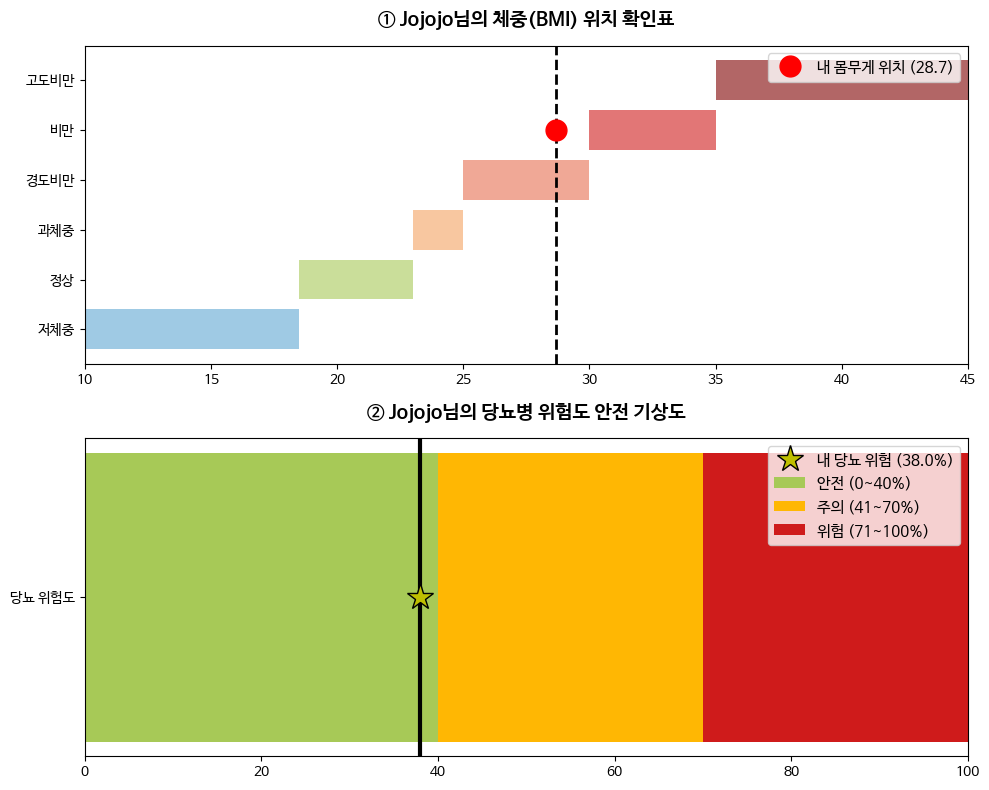


 ▣ Jojojo 어르신을 위한 맞춤형 식생활 가이드라인
[ 체중 관리 조언 ]
 ▷ 무리하게 굶는 것보다 밥 양을 평소보다 '3분의 1공기'만 줄여보시고, 국물보단 건더기 위주로 드셔보세요.
 ▷ 달달한 믹스커피 대신 따뜻한 보리차를 드시는 습관이 체중 감량에 큰 도움이 됩니다.
------------------------------------------------------------
[ 당뇨병 예방 및 혈당 관리 식습관 ]
 ① 식사 순서 바꾸기: 식사하실 때 [ 나물/채소 ▷ 고기/생선 ▷ 밥 ] 순서로 드시면 혈당이 천천히 올라가요.
 ② 흰쌀밥 대신 잡곡밥: 흰쌀밥 대신 현미나 보리, 잡곡을 섞어 드시는 것이 훨씬 건강합니다.
 ③ 식후 가벼운 산책: 식사를 마치고 20~30분 뒤에 동네를 가볍게 한 바퀴 걸으시면 혈당이 쑥 내려갑니다.

★★★★★★★★★★★★★★★★★★★★★★★★★
 🔍 [어르신 전용] 병원에서 들은 어려운 의학 용어 돋보기 
★★★★★★★★★★★★★★★★★★★★★★★★★
※ 당뇨, 혈당, 혈압, 콜레스테롤 등 궁금한 단어를 입력해 보세요.
※ 사전을 끝내고 싶으시면 '종료'라고 입력하시면 됩니다.



KeyboardInterrupt: Interrupted by user

In [ ]:
predict_health_risk()